# Red Neuronal v2 (ResNet-MLP) — Entrenamiento Cloud (Kaggle Notebooks + GPU)

**Proyecto:** MECMT07 — Home Credit Default Risk  
**Versión:** v2 — Arquitectura ResNet-style MLP  
**Plataforma:** Kaggle Notebooks con GPU P100 gratuita  
**Dataset fuente:** `mecmt07-features` (Dataset privado de Kaggle)

**Diferencias respecto a nn-cloud-train.ipynb (v1):**
- **Arquitectura ResNet-MLP** con skip connections en lugar de MLP plano
- Cada bloque residual: `LayerNorm → Dense(dim, gelu) → Dropout → Dense(dim) → Add(skip)`
- `LayerNorm` en lugar de `BatchNorm` (más estable en residual networks)
- Activación `GELU` en lugar de `ReLU` (más suave, mejor gradiente)
- Espacio de búsqueda Optuna ampliado: `n_blocks` [2-6], `dim` [64-512]

**Motivación:** Las skip connections permiten redes más profundas sin degradación de gradiente, explorando si la mayor capacidad mejora el AUC sobre el MLP base (val AUC = 0.7673).

**Estrategia:**
- Preprocessing: `SimpleImputer(median)` + `StandardScaler` (igual que v1)
- Split: 80/20 estratificado para Optuna
- Optuna 15 trials: objetivo = val AUC − 0.5 · gap
- GPU P100 con CUDA

**Outputs en `/kaggle/working/`:**
- `nn2_cloud_best.keras` — modelo final Keras
- `nn2_cloud_preproc.pkl` — imputer + scaler (joblib)
- `nn2_cloud_metadata.json` — hiperparámetros, AUC, arquitectura
- `nn2_cloud_optuna_trials.csv` — historial de trials

In [ ]:
# ─── Instalar dependencias ────────────────────────────────────────────────────
!pip install optuna --quiet
print('Dependencias listas.')

Dependencias listas.


In [ ]:
# ─── Verificar GPU ────────────────────────────────────────────────────────────
import subprocess as sp
try:
    result = sp.run(['nvidia-smi', '--query-gpu=name,memory.total',
                     '--format=csv,noheader'],
                    capture_output=True, text=True, timeout=10)
    if result.returncode == 0:
        print(f'GPU detectada: {result.stdout.strip()}')
        USE_GPU = True
    else:
        print('nvidia-smi falló — modo CPU')
        USE_GPU = False
except Exception:
    print('nvidia-smi no disponible — modo CPU')
    USE_GPU = False

print(f'USE_GPU = {USE_GPU}')

GPU detectada: Tesla P100-PCIE-16GB, 16384 MiB
USE_GPU = True


In [ ]:
# ─── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import json
import joblib
import time
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

import tensorflow as tf
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU disponible     : {len(tf.config.list_physical_devices("GPU")) > 0}')
print(f'optuna version     : {optuna.__version__}')
print('Imports OK')

2026-02-28 01:02:51.927789: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772240572.111900      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772240572.168493      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772240572.634732      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772240572.634796      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772240572.634800      55 computation_placer.cc:177] computation placer alr

TensorFlow version : 2.19.0
GPU disponible     : True
optuna version     : 4.7.0
Imports OK


In [ ]:
# ─── Configuración ────────────────────────────────────────────────────────────
SEED     = 42
N_TRIALS = 15

DATA_DIR  = Path('/kaggle/input/datasets/davidguzzi/mecmt07-features')
MODEL_DIR = Path('/kaggle/working')

plt.rcParams['figure.dpi']         = 100
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False

np.random.seed(SEED)
tf.random.set_seed(SEED)

print('=' * 65)
print('CONFIGURACIÓN — Red Neuronal v2 (ResNet-MLP)')
print('=' * 65)
print(f'  DATA_DIR  : {DATA_DIR}')
print(f'  MODEL_DIR : {MODEL_DIR}')
print(f'  N_TRIALS  : {N_TRIALS}')
print(f'  SEED      : {SEED}')
print(f'  GPU       : {USE_GPU}')
print('=' * 65)
for f in ['features_train.parquet', 'features_test.parquet']:
    exists = (DATA_DIR / f).exists()
    print(f'  {f}: {"OK" if exists else "NO encontrado"}')

CONFIGURACIÓN — Red Neuronal v2 (ResNet-MLP)
  DATA_DIR  : /kaggle/input/datasets/davidguzzi/mecmt07-features
  MODEL_DIR : /kaggle/working
  N_TRIALS  : 15
  SEED      : 42
  GPU       : True
  features_train.parquet: OK
  features_test.parquet: OK


In [ ]:
# ─── Cargar datos + preprocessing ─────────────────────────────────────────────
print('Cargando datos...')
df      = pd.read_parquet(DATA_DIR / 'features_train.parquet')
df_test = pd.read_parquet(DATA_DIR / 'features_test.parquet')

feature_cols = [c for c in df.columns if c not in ('SK_ID_CURR', 'TARGET')]

# Encodear columnas categóricas (object dtype) → enteros, preservando NaN
cat_cols = [c for c in feature_cols if df[c].dtype == 'object']
if cat_cols:
    print(f'  Columnas categóricas encontradas: {cat_cols}')
    for col in cat_cols:
        cats    = pd.concat([df[col], df_test[col]]).dropna().unique()
        mapping = {v: i for i, v in enumerate(cats)}
        df[col]      = df[col].map(mapping)
        df_test[col] = df_test[col].map(mapping)
else:
    print('  Sin columnas categóricas')

X_raw       = df[feature_cols].values
y           = df['TARGET'].values
X_test_raw  = df_test[feature_cols].values
sk_ids_test = df_test['SK_ID_CURR'].values

print(f'\nTrain: {X_raw.shape}  | Default rate: {y.mean():.2%}')
print(f'Test : {X_test_raw.shape}')

# Preprocessing: SimpleImputer + StandardScaler
print('Preprocesando (SimpleImputer + StandardScaler)...')
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

X_imp      = imputer.fit_transform(X_raw)
X_scaled   = scaler.fit_transform(X_imp)

X_test_imp    = imputer.transform(X_test_raw)
X_test_scaled = scaler.transform(X_test_imp)

# Split 80/20 estratificado para Optuna
X_tr, X_val, y_tr, y_val = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=SEED
)
print(f'Train split: {X_tr.shape} | Val split: {X_val.shape}')

# Class weights
class_weight = {0: 1.0, 1: float((y == 0).sum()) / float((y == 1).sum())}
print(f'class_weight: {class_weight}')

INPUT_DIM = X_scaled.shape[1]

Cargando datos...
  Sin columnas categóricas

Train: (307511, 30)  | Default rate: 8.07%
Test : (48744, 30)
Preprocesando (SimpleImputer + StandardScaler)...
Train split: (246008, 30) | Val split: (61503, 30)
class_weight: {0: 1.0, 1: 11.387150050352467}


In [ ]:
# ─── Funciones auxiliares ─────────────────────────────────────────────────────
def compute_metrics(y_true, y_prob, threshold=0.5, label='Model'):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    auc  = roc_auc_score(y_true, y_prob)
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    return dict(Model=label, AUC=round(auc, 4),
                N=len(y_true), P=int(y_pred.sum()),
                TP=int(tp), TN=int(tn), FP=int(fp), FN=int(fn),
                Recall=round(rec, 4), Precision=round(prec, 4), F1=round(f1, 4))

print('Funciones auxiliares definidas.')

Funciones auxiliares definidas.


## 1. Arquitectura ResNet-MLP

Cada bloque residual aplica:
$$\mathbf{x}_{l+1} = \mathbf{x}_l + \text{Dense}(\text{Dropout}(\text{GELU}(\text{Dense}(\text{LayerNorm}(\mathbf{x}_l)))))$$

La skip connection $\mathbf{x}_l$ permite que el gradiente fluya directamente sin degradarse, habilitando redes más profundas.

In [ ]:
# ─── Arquitectura ResNet-MLP ──────────────────────────────────────────────────
def build_resnet_model(n_blocks, dim, dropout_rate, learning_rate, input_dim):
    """
    ResNet-style MLP para clasificación tabular.
    
    Arquitectura:
      Input(input_dim)
      → Dense(dim)                           # proyección inicial
      → [LayerNorm → Dense(dim, gelu) → Dropout → Dense(dim) → Add(skip)] × n_blocks
      → LayerNorm
      → Dense(1, sigmoid)
    """
    inputs = tf.keras.Input(shape=(input_dim,), name='input')

    # Proyección inicial: input_dim → dim
    x = tf.keras.layers.Dense(dim, name='proj')(inputs)

    # Bloques residuales
    for i in range(n_blocks):
        skip = x
        x = tf.keras.layers.LayerNormalization(name=f'ln_{i}')(x)
        x = tf.keras.layers.Dense(dim, activation='gelu', name=f'fc1_{i}')(x)
        x = tf.keras.layers.Dropout(dropout_rate, name=f'drop_{i}')(x)
        x = tf.keras.layers.Dense(dim, name=f'fc2_{i}')(x)
        x = tf.keras.layers.Add(name=f'skip_{i}')([x, skip])  # skip connection

    # Normalización final + cabezal de clasificación
    x = tf.keras.layers.LayerNormalization(name='ln_final')(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid', name='output')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )
    return model

# Test rápido de la arquitectura
_m = build_resnet_model(n_blocks=3, dim=128, dropout_rate=0.3,
                        learning_rate=1e-3, input_dim=INPUT_DIM)
print(f'ResNet-MLP (3 bloques × 128): {_m.count_params():,} parámetros')
_m.summary()
del _m

I0000 00:00:1772240597.764769      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


ResNet-MLP (3 bloques × 128): 104,193 parámetros


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 30)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj (Dense)        │ (None, 128)       │      3,968 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_0                │ (None, 128)       │        256 │ proj[0][0]        │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1_0 (Dense)       │ (None, 128)       │     16,512 │ ln_0[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_0 (Dropout)    │ (None, 128)       │          0 │ fc1_0[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc2_0 (Dense)       │ (None, 128)       │     16,512 │ drop_0[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_0 (Add)        │ (None, 128)       │          0 │ fc2_0[0][0],      │
│                     │                   │            │ proj[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_1                │ (None, 128)       │        256 │ skip_0[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1_1 (Dense)       │ (None, 128)       │     16,512 │ ln_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_1 (Dropout)    │ (None, 128)       │          0 │ fc1_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc2_1 (Dense)       │ (None, 128)       │     16,512 │ drop_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_1 (Add)        │ (None, 128)       │          0 │ fc2_1[0][0],      │
│                     │                   │            │ skip_0[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_2                │ (None, 128)       │        256 │ skip_1[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1_2 (Dense)       │ (None, 128)       │     16,512 │ ln_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_2 (Dropout)    │ (None, 128)       │          0 │ fc1_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc2_2 (Dense)       │ (None, 128)       │     16,512 │ drop_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_2 (Add)        │ (None, 128)       │          0 │ fc2_2[0][0],      │
│                     │                   │            │ skip_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_final            │ (None, 128)       │        256 │ skip_2[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        129 │ ln_final[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 104,193 (407.00 KB)

 Trainable params: 104,193 (407.00 KB)

 Non-trainable params: 0 (0.00 B)

## 2. Optuna — Búsqueda de Hiperparámetros

**Función objetivo** con split 80/20:
$$\text{objetivo} = \text{AUC}_{\text{val}} - 0.5 \cdot \max(0,\ \text{AUC}_{\text{train}} - \text{AUC}_{\text{val}})$$

**Espacio de búsqueda:**
| Parámetro | Tipo | Rango |
|-----------|------|-------|
| `n_blocks` | int | [2, 6] |
| `dim` | categorical | [64, 128, 256, 512] |
| `dropout_rate` | float | [0.1, 0.5] |
| `learning_rate` | float log | [1e-4, 1e-2] |
| `batch_size` | categorical | [256, 512, 1024] |

In [ ]:
# ─── Optuna objective ─────────────────────────────────────────────────────────
trial_stats = {}

def objective(trial):
    tf.random.set_seed(SEED + trial.number)

    n_blocks      = trial.suggest_int('n_blocks', 2, 6)
    dim           = trial.suggest_categorical('dim', [64, 128, 256, 512])
    dropout_rate  = trial.suggest_float('dropout_rate', 0.1, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size    = trial.suggest_categorical('batch_size', [256, 512, 1024])

    model = build_resnet_model(n_blocks, dim, dropout_rate, learning_rate, INPUT_DIM)

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=batch_size,
        class_weight=class_weight,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor='val_auc', patience=10, mode='max',
                restore_best_weights=True
            )
        ],
        verbose=0,
    )

    best_ep   = int(np.argmax(history.history['val_auc']))
    val_auc   = history.history['val_auc'][best_ep]
    train_auc = history.history['auc'][best_ep]

    trial.set_user_attr('val_auc',    val_auc)
    trial.set_user_attr('train_auc',  train_auc)
    trial.set_user_attr('best_epoch', best_ep + 1)

    gap = max(0.0, train_auc - val_auc)
    trial_stats[trial.number] = {'val': val_auc, 'train': train_auc, 'gap': gap}
    return val_auc - 0.5 * gap

def _optuna_callback(study, trial):
    stats  = trial_stats.get(trial.number, {})
    val    = stats.get('val', trial.value)
    gap    = stats.get('gap', 0.0)
    ep     = trial.user_attrs.get('best_epoch', '?')
    marker = ' ◀ best' if trial.number == study.best_trial.number else ''
    print(f'  Trial {trial.number + 1:>2}/{N_TRIALS} │ '
          f'obj={trial.value:.5f}  val={val:.5f}  gap={gap:.5f}  ep={ep}  │  '
          f'best={study.best_value:.5f}{marker}')

print('=' * 65)
print('OPTUNA — BÚSQUEDA DE HIPERPARÁMETROS (ResNet-MLP)')
print('=' * 65)
print(f'  Trials     : {N_TRIALS}')
print(f'  Split      : 80/20 estratificado')
print(f'  Arquitectura: Input({INPUT_DIM}) → Dense(dim) → [ResBlock × n_blocks] → Dense(1)')
print(f'  GPU        : {USE_GPU}')
print('─' * 65)

t_opt = time.time()
study = optuna.create_study(
    direction = 'maximize',
    sampler   = optuna.samplers.TPESampler(seed=SEED)
)
study.optimize(objective, n_trials=N_TRIALS,
               show_progress_bar=False, callbacks=[_optuna_callback])

elapsed_opt = time.time() - t_opt
print('─' * 65)
print(f'Búsqueda finalizada en {elapsed_opt/60:.1f} min')

best = study.best_trial
print(f'\nMejores hiperparámetros:')
for k, v in best.params.items():
    print(f'  {k:<16}: {v}')
print(f'  best_epoch  : {best.user_attrs["best_epoch"]}')
print(f'\nObjetivo (val AUC penalizado): {best.value:.5f}')

OPTUNA — BÚSQUEDA DE HIPERPARÁMETROS (ResNet-MLP)
  Trials     : 15
  Split      : 80/20 estratificado
  Arquitectura: Input(30) → Dense(dim) → [ResBlock × n_blocks] → Dense(1)
  GPU        : True
─────────────────────────────────────────────────────────────────


I0000 00:00:1772240603.132674     131 service.cc:152] XLA service 0x7bcf440095e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772240603.132711     131 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772240603.869464     131 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772240606.869075     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  Trial  1/15 │ obj=0.76159  val=0.76372  gap=0.00424  ep=17  │  best=0.76159 ◀ best
  Trial  2/15 │ obj=0.76010  val=0.76275  gap=0.00529  ep=14  │  best=0.76159
  Trial  3/15 │ obj=0.76316  val=0.76340  gap=0.00047  ep=12  │  best=0.76316 ◀ best
  Trial  4/15 │ obj=0.76408  val=0.76432  gap=0.00048  ep=13  │  best=0.76408 ◀ best
  Trial  5/15 │ obj=0.76385  val=0.76445  gap=0.00120  ep=14  │  best=0.76408
  Trial  6/15 │ obj=0.76512  val=0.76588  gap=0.00153  ep=49  │  best=0.76512 ◀ best
  Trial  7/15 │ obj=0.76547  val=0.76547  gap=0.00000  ep=18  │  best=0.76547 ◀ best
  Trial  8/15 │ obj=0.76228  val=0.76523  gap=0.00592  ep=36  │  best=0.76547
  Trial  9/15 │ obj=0.76206  val=0.76369  gap=0.00327  ep=15  │  best=0.76547
  Trial 10/15 │ obj=0.76361  val=0.76466  gap=0.00209  ep=17  │  best=0.76547
  Trial 11/15 │ obj=0.76484  val=0.76484  gap=0.00000  ep=10  │  best=0.76547
  Trial 12/15 │ obj=0.76613  val=0.76613  gap=0.00000  ep=49  │  best=0.76613 ◀ best
  Trial 13/15 │ obj=0.

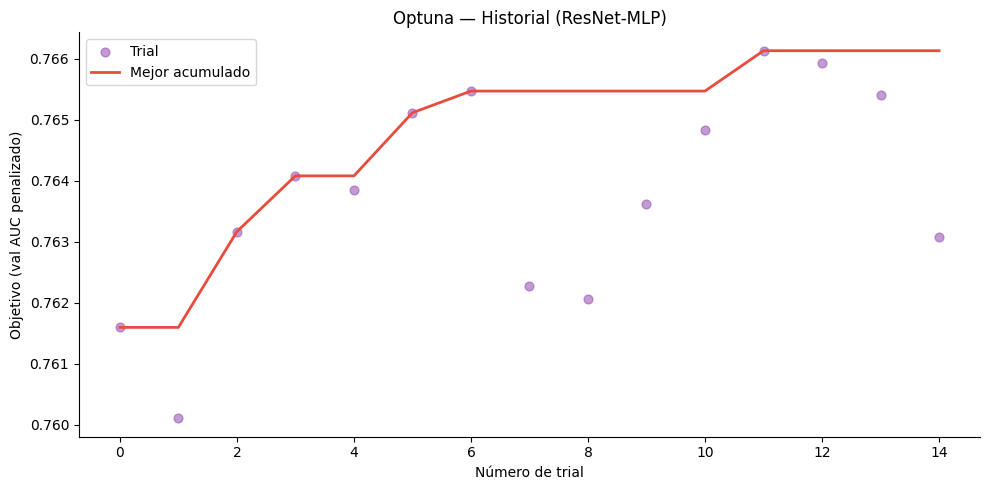

Gráfico guardado: nn2_optuna_history.png


In [ ]:
# ─── Historial de Optuna ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
trials_nums = [t.number for t in study.trials]
trials_vals = [t.value  for t in study.trials]
best_so_far, cur = [], float('-inf')
for v in trials_vals:
    cur = max(cur, v)
    best_so_far.append(cur)

ax.scatter(trials_nums, trials_vals, alpha=0.6, s=40, color='#9b59b6', label='Trial')
ax.plot(trials_nums, best_so_far, color='#e74c3c', lw=2, label='Mejor acumulado')
ax.set_xlabel('Número de trial')
ax.set_ylabel('Objetivo (val AUC penalizado)')
ax.set_title('Optuna — Historial (ResNet-MLP)')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / 'nn2_optuna_history.png', dpi=120)
plt.show()
print('Gráfico guardado: nn2_optuna_history.png')

## 3. Modelo Final — Refit con Mejores Hiperparámetros

In [ ]:
# ─── Entrenar modelo final ────────────────────────────────────────────────────
tf.random.set_seed(SEED)

best_p = study.best_trial.params

model_final = build_resnet_model(
    best_p['n_blocks'], best_p['dim'],
    best_p['dropout_rate'], best_p['learning_rate'],
    INPUT_DIM
)

n_params = model_final.count_params()
print(f'Entrenando modelo final (ResNet-MLP)...')
print(f'  Arquitectura: {best_p["n_blocks"]} bloques × dim={best_p["dim"]}')
print(f'  Parámetros  : {n_params:,}')
print(f'  Dropout     : {best_p["dropout_rate"]:.3f}  |  lr: {best_p["learning_rate"]:.6f}')
print(f'  Batch size  : {best_p["batch_size"]}')
print(f'{"-" * 60}')

t0 = time.time()
history_final = model_final.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=best_p['batch_size'],
    class_weight=class_weight,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_auc', patience=15, mode='max',
            restore_best_weights=True
        )
    ],
    verbose=0,
)

best_ep_final = int(np.argmax(history_final.history['val_auc']))

y_prob_val  = model_final.predict(X_val, verbose=0).ravel()
y_prob_full = model_final.predict(X_scaled, verbose=0).ravel()

val_auc_final  = roc_auc_score(y_val,  y_prob_val)
train_auc_full = roc_auc_score(y,      y_prob_full)

elapsed_final = time.time() - t0
print(f'  Entrenamiento finalizado en {elapsed_final:.0f}s  |  mejor época: {best_ep_final + 1}')
print(f'  Val AUC (20%)  : {val_auc_final:.5f}')
print(f'  Train AUC full : {train_auc_full:.5f}')
print(f'  Gap            : {abs(train_auc_full - val_auc_final):.5f}')
print(f'{"-" * 60}')

Entrenando modelo final (ResNet-MLP)...
  Arquitectura: 4 bloques × dim=128
  Parámetros  : 137,473
  Dropout     : 0.491  |  lr: 0.000112
  Batch size  : 1024
------------------------------------------------------------
  Entrenamiento finalizado en 105s  |  mejor época: 47
  Val AUC (20%)  : 0.76599
  Train AUC full : 0.77121
  Gap            : 0.00521
------------------------------------------------------------


## 4. Métricas y Visualizaciones

In [ ]:
# ─── Métricas ─────────────────────────────────────────────────────────────────
metrics_train = compute_metrics(y,     y_prob_full, label='NN2 ResNet (train in-sample)')
metrics_val   = compute_metrics(y_val, y_prob_val,  label='NN2 ResNet (val 20%)')

print('=' * 65)
print('RED NEURONAL v2 (ResNet-MLP) — MÉTRICAS FINALES')
print('=' * 65)
for m in [metrics_train, metrics_val]:
    print(f"\n{m['Model']}")
    print(f"  AUC={m['AUC']:.4f}  Recall={m['Recall']:.4f}  "
          f"Precision={m['Precision']:.4f}  F1={m['F1']:.4f}")
    print(f"  TP={m['TP']:,}  TN={m['TN']:,}  FP={m['FP']:,}  FN={m['FN']:,}")
print('=' * 65)

display(pd.DataFrame([metrics_train, metrics_val]).set_index('Model'))

RED NEURONAL v2 (ResNet-MLP) — MÉTRICAS FINALES

NN2 ResNet (train in-sample)
  AUC=0.7712  Recall=0.7023  Precision=0.1706  F1=0.2745
  TP=17,435  TN=197,913  FP=84,773  FN=7,390

NN2 ResNet (val 20%)
  AUC=0.7660  Recall=0.6997  Precision=0.1699  F1=0.2734
  TP=3,474  TN=39,566  FP=16,972  FN=1,491


,AUC,N,P,TP,TN,FP,FN,Recall,Precision,F1
Model,,,,,,,,,,
NN2 ResNet (train in-sample),0.7712,307511,102208,17435,197913,84773,7390,0.7023,0.1706,0.2745
NN2 ResNet (val 20%),0.7660,61503,20446,3474,39566,16972,1491,0.6997,0.1699,0.2734


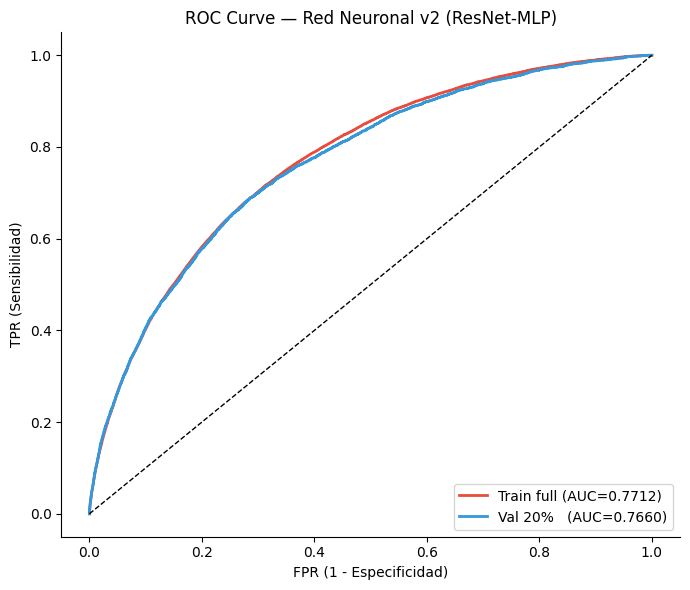

Gráfico guardado: nn2_roc_curve.png


In [ ]:
# ─── Curvas ROC ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
for y_true, y_prob, label, color in [
        (y,     y_prob_full, f'Train full (AUC={train_auc_full:.4f})', '#e74c3c'),
        (y_val, y_prob_val,  f'Val 20%   (AUC={val_auc_final:.4f})',   '#3498db')]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=label)
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('FPR (1 - Especificidad)')
ax.set_ylabel('TPR (Sensibilidad)')
ax.set_title('ROC Curve — Red Neuronal v2 (ResNet-MLP)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(MODEL_DIR / 'nn2_roc_curve.png', dpi=120)
plt.show()
print('Gráfico guardado: nn2_roc_curve.png')

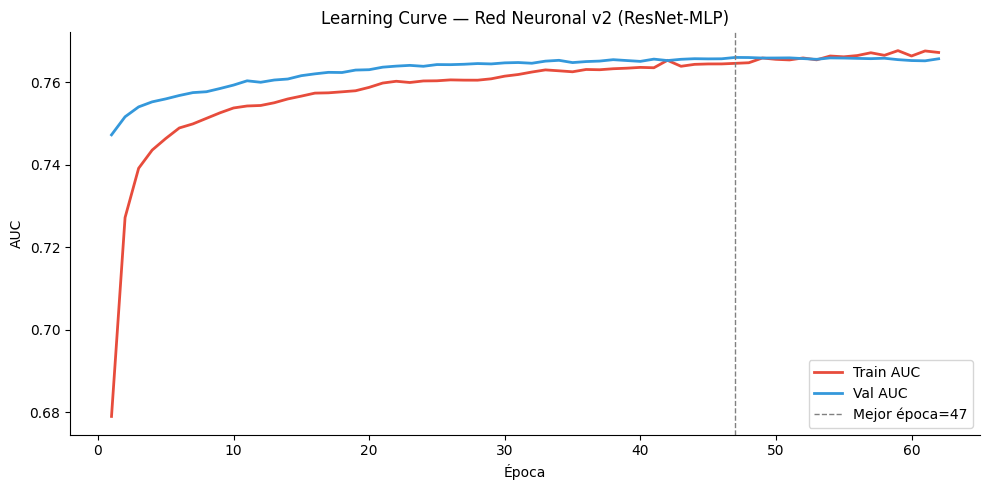

Gráfico guardado: nn2_learning_curve.png


In [ ]:
# ─── Curva de aprendizaje ─────────────────────────────────────────────────────
epochs_range = range(1, len(history_final.history['auc']) + 1)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs_range, history_final.history['auc'],     color='#e74c3c', lw=2, label='Train AUC')
ax.plot(epochs_range, history_final.history['val_auc'], color='#3498db', lw=2, label='Val AUC')
ax.axvline(best_ep_final + 1, color='gray', linestyle='--', lw=1,
           label=f'Mejor época={best_ep_final+1}')
ax.set_xlabel('Época')
ax.set_ylabel('AUC')
ax.set_title('Learning Curve — Red Neuronal v2 (ResNet-MLP)')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / 'nn2_learning_curve.png', dpi=120)
plt.show()
print('Gráfico guardado: nn2_learning_curve.png')

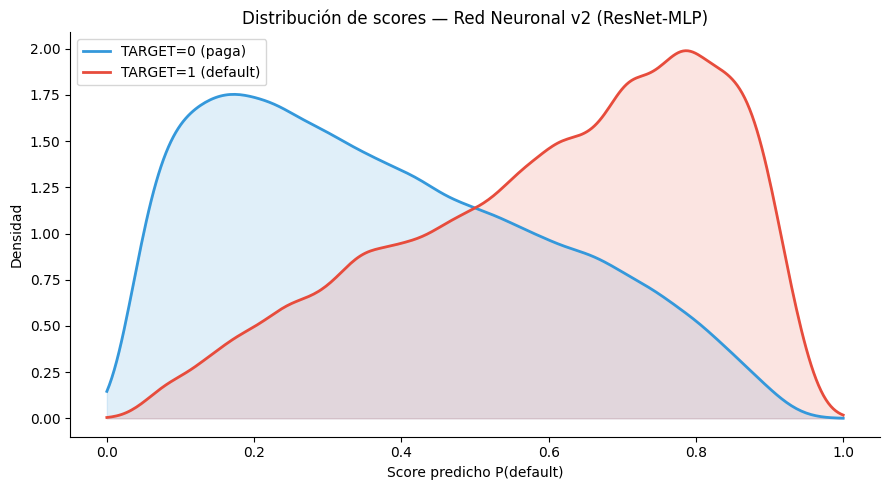

Gráfico guardado: nn2_score_distribution.png


In [ ]:
# ─── Distribución de scores ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
for val, color, label in [(0, '#3498db', 'TARGET=0 (paga)'),
                           (1, '#e74c3c', 'TARGET=1 (default)')]:
    probs = y_prob_full[y == val]
    kde   = gaussian_kde(probs, bw_method=0.1)
    xs    = np.linspace(0, 1, 300)
    ax.plot(xs, kde(xs), color=color, lw=2, label=label)
    ax.fill_between(xs, kde(xs), alpha=0.15, color=color)
ax.set_xlabel('Score predicho P(default)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de scores — Red Neuronal v2 (ResNet-MLP)')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / 'nn2_score_distribution.png', dpi=120)
plt.show()
print('Gráfico guardado: nn2_score_distribution.png')

## 5. Guardar Modelo y Metadata

In [ ]:
# ─── Guardar modelo y artefactos ──────────────────────────────────────────────
model_path   = MODEL_DIR / 'nn2_cloud_best.keras'
preproc_path = MODEL_DIR / 'nn2_cloud_preproc.pkl'
meta_path    = MODEL_DIR / 'nn2_cloud_metadata.json'
trials_path  = MODEL_DIR / 'nn2_cloud_optuna_trials.csv'

model_final.save(str(model_path))
joblib.dump({'imputer': imputer, 'scaler': scaler}, preproc_path)

metadata = {
    'best_params'    : best_p,
    'best_epoch'     : int(best_ep_final + 1),
    'val_auc'        : round(val_auc_final, 6),
    'train_auc'      : round(train_auc_full, 6),
    'n_params'       : int(n_params),
    'architecture'   : f'ResNet-MLP: {best_p["n_blocks"]} bloques x dim={best_p["dim"]}',
    'n_trials'       : N_TRIALS,
    'feature_cols'   : feature_cols,
    'use_gpu'        : USE_GPU,
    'tf_version'     : tf.__version__,
    'timestamp'      : pd.Timestamp.now().isoformat()
}
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)

trials_df = study.trials_dataframe()
trials_df.to_csv(trials_path, index=False)

print('=' * 65)
print('ARTEFACTOS GUARDADOS')
print('=' * 65)
print(f'  {model_path.name:<45} ({model_path.stat().st_size/1e6:.2f} MB)')
print(f'  {preproc_path.name:<45} ({preproc_path.stat().st_size/1e6:.2f} MB)')
print(f'  {meta_path.name}')
print(f'  {trials_path.name}')
print('=' * 65)
print('\n>>> Descargar desde el Output tab de Kaggle:')
print(f'    - {model_path.name}')
print(f'    - {preproc_path.name}')
print(f'    - {meta_path.name}')
print('\n>>> Luego correr localmente: nn2_cloud_predict.ipynb')

ARTEFACTOS GUARDADOS
  nn2_cloud_best.keras                          (1.76 MB)
  nn2_cloud_preproc.pkl                         (0.00 MB)
  nn2_cloud_metadata.json
  nn2_cloud_optuna_trials.csv

>>> Descargar desde el Output tab de Kaggle:
    - nn2_cloud_best.keras
    - nn2_cloud_preproc.pkl
    - nn2_cloud_metadata.json

>>> Luego correr localmente: nn2_cloud_predict.ipynb


## Resumen Final

In [ ]:
# ─── Resumen ──────────────────────────────────────────────────────────────────
import platform
print('=' * 65)
print('RED NEURONAL v2 (ResNet-MLP) — RESUMEN FINAL')
print('=' * 65)
print(f'  Val AUC (20%)     : {val_auc_final:.5f}')
print(f'  Train AUC (full)  : {train_auc_full:.5f}')
print(f'  Gap               : {abs(train_auc_full - val_auc_final):.5f}')
print(f'  Parámetros        : {n_params:,}')
print(f'  n_train           : {X_scaled.shape[0]:,}')
print('─' * 65)
print(f'  Mejores hiperparámetros:')
for k, v in best_p.items():
    print(f'    {k:<16}: {v}')
print(f'  best_epoch        : {best_ep_final + 1}')
print('─' * 65)
print(f'  TensorFlow : {tf.__version__}')
print(f'  optuna     : {optuna.__version__}')
print(f'  numpy      : {np.__version__}')
print(f'  GPU        : {USE_GPU}')
print(f'  Python     : {platform.python_version()}')
print(f'  Timestamp  : {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")}')
print('=' * 65)

RED NEURONAL v2 (ResNet-MLP) — RESUMEN FINAL
  Val AUC (20%)     : 0.76599
  Train AUC (full)  : 0.77121
  Gap               : 0.00521
  Parámetros        : 137,473
  n_train           : 307,511
─────────────────────────────────────────────────────────────────
  Mejores hiperparámetros:
    n_blocks        : 4
    dim             : 128
    dropout_rate    : 0.49139350528504905
    learning_rate   : 0.00011175260243994949
    batch_size      : 1024
  best_epoch        : 47
─────────────────────────────────────────────────────────────────
  TensorFlow : 2.19.0
  optuna     : 4.7.0
  numpy      : 2.0.2
  GPU        : True
  Python     : 3.12.12
  Timestamp  : 2026-02-28 01:22:53
